|                |   |
:----------------|---|
| **Nombre**     | Elisa Aguirre Arias  |
| **Fecha**      | 16/04/2026  |
| **Expediente** | 738894 |

# Examen 2

Utiliza optimización bayesiana para intentar encontrar el mínimo global de la siguiente función:
donde las 3 variables están acotadas en [0, 1].
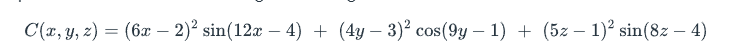
Crea 5 muestras iniciales aleatorias e itera 15 veces para optimizar.
Explica por qué optimización bayesiana es una elección buena para este problema en lugar de GridSearch.








In [ ]:
def f(x,y,z):
    return ((6x-2)**2)*(np.sin(12x-4))
    ((4y-3)**2)*(np.cos(9y-1))
    ((5z-1)**2)*(np.sin(8z-4))

# Datos iniciales
X = np.array([[-10], [0], [10]])
y = f(X)

# Modelo
gp = GaussianProcessRegressor(n_restarts_optimizer=10)

# Simulación de puntos
X_sim = np.linspace(-5*np.pi, 5*np.pi, 1000).reshape(-1, 1)

# Iteraciones
for i in range(5):
    gp.fit(X, y)
    y_pred, sigma = gp.predict(X_sim, return_std=True)

    y_upper = y_pred + 2*sigma
    y_lower = y_pred - 2*sigma

    i_max = np.argmax(y_upper)
    x_max = X_sim[i_max].reshape(1,1)
    y_max = f(x_max)

    i_min = np.argmin(y_lower)
    x_min = X_sim[i_min].reshape(1,1)
    y_min = f(x_min)

    i_unc = np.argmax(sigma)
    x_unc = X_sim[i_unc].reshape(1,1)
    y_unc = f(x_unc)

    # Elegir un criterio
    x_new = x_max
    y_new = y_max

    # Agregar nuevo punto
    X = np.vstack((X, x_new))
    y = np.vstack((y, y_new))

# Gráfica
plt.figure(figsize=(10,6))

plt.plot(X_sim, y_pred, label="Predicción")

plt.fill_between(
    X_sim.ravel(),
    y_lower,
    y_upper,
    alpha=0.2,
    label="Intervalo de confianza"
)

plt.scatter(X, y, color="red", label="Muestras")

plt.legend()
plt.grid()
plt.title("Gaussian Process + Optimización Bayesiana")
plt.show()

El dataset adidas contiene información acerca de productos y la calificación que se les dio por usuarios. Utiliza regresión logística para conseguir un modelo que nos ayude a decidir si un producto será clasificado como bueno (average_rating>=4.3). Crea al menos 2 interacciones entre diferentes factores.
Encuentra la significancia estadística de los factores utilizados.
Cross-validation a utilizar: Train-test.
Métrico a utilizar: Accuracy. Explica el significado del score que arroje tu modelo. Analiza el resultado de los p-values encontrados.

In [27]:
import pandas as pd 
import numpy as np

In [28]:
df= pd.read_csv(r"C:\Users\elisa\Downloads\adidas.csv")
df.head()

,url,name,sku,selling_price,original_price,currency,availability,color,category,source,source_website,breadcrumbs,description,brand,images,country,language,average_rating,reviews_count,crawled_at
0,https://www.adidas.com/us/beach-shorts/FJ5089....,Beach Shorts,FJ5089,40,NaN,USD,InStock,Black,Clothing,adidas United States,https://www.adidas.com,Women/Clothing,Splashing in the surf. Making memories with yo...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.5,35,2021-10-23 17:50:17.331255
1,https://www.adidas.com/us/five-ten-kestrel-lac...,Five Ten Kestrel Lace Mountain Bike Shoes,BC0770,150,NaN,USD,InStock,Grey,Shoes,adidas United States,https://www.adidas.com,Women/Shoes,Lace up and get after it. The Five Ten Kestrel...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.8,4,2021-10-23 17:50:17.423830
2,https://www.adidas.com/us/mexico-away-jersey/G...,Mexico Away Jersey,GC7946,70,NaN,USD,InStock,White,Clothing,adidas United States,https://www.adidas.com,Kids/Clothing,"Clean and crisp, this adidas Mexico Away Jerse...",adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.9,42,2021-10-23 17:50:17.530834
3,https://www.adidas.com/us/five-ten-hiangle-pro...,Five Ten Hiangle Pro Competition Climbing Shoes,FV4744,160,NaN,USD,InStock,Black,Shoes,adidas United States,https://www.adidas.com,Five Ten/Shoes,The Hiangle Pro takes on the classic shape of ...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,3.7,7,2021-10-23 17:50:17.615054
4,https://www.adidas.com/us/mesh-broken-stripe-p...,Mesh Broken-Stripe Polo Shirt,GM0239,65,NaN,USD,InStock,Blue,Clothing,adidas United States,https://www.adidas.com,Men/Clothing,Step up to the tee relaxed. This adidas golf p...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.7,11,2021-10-23 17:50:17.702680


In [29]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   url             845 non-null    object 
 1   name            845 non-null    object 
 2   sku             845 non-null    object 
 3   selling_price   845 non-null    int64  
 4   original_price  829 non-null    object 
 5   currency        845 non-null    object 
 6   availability    845 non-null    object 
 7   color           845 non-null    object 
 8   category        845 non-null    object 
 9   source          845 non-null    object 
 10  source_website  845 non-null    object 
 11  breadcrumbs     845 non-null    object 
 12  description     845 non-null    object 
 13  brand           845 non-null    object 
 14  images          845 non-null    object 
 15  country         845 non-null    object 
 16  language        845 non-null    object 
 17  average_rating  845 non-null    flo

,selling_price,average_rating,reviews_count
count,845.000000,845.000000,845.000000
mean,53.192899,4.608402,426.178698
std,31.411645,0.293795,1229.158277
min,9.000000,1.000000,1.000000
25%,28.000000,4.500000,19.000000
50%,48.000000,4.700000,68.000000
75%,70.000000,4.800000,314.000000
max,240.000000,5.000000,11750.000000


In [30]:
df.isnull().sum()

url                0
name               0
sku                0
selling_price      0
original_price    16
currency           0
availability       0
color              0
category           0
source             0
source_website     0
breadcrumbs        0
description        0
brand              0
images             0
country            0
language           0
average_rating     0
reviews_count      0
crawled_at         0
dtype: int64

In [31]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

In [32]:
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\elisa\AppData\Local\Temp\ipykernel_4452\3440666652.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\elisa\AppData\Local\Temp\ipykernel_4452\3440666652.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [33]:
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

In [34]:
df.isnull().sum()

url               0
name              0
sku               0
selling_price     0
original_price    0
currency          0
availability      0
color             0
category          0
source            0
source_website    0
breadcrumbs       0
description       0
brand             0
images            0
country           0
language          0
average_rating    0
reviews_count     0
crawled_at        0
dtype: int64

In [35]:
df['target']=(df['average_rating']>=4.3).astype(int)

In [36]:
df=pd.get_dummies(df,drop_first=True)

In [37]:
df['int1']=df['reviews_count']*df['average_rating']
df['int2']=df['reviews_count']**2

In [38]:
x=df.drop(['target','average_rating'],axis=1)
y=df['target']

In [39]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [40]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [42]:
y_pred=model.predict(x_test)

In [43]:
acc=(y_pred==y_test).mean()
print("Accuracy:",acc)

Accuracy: 0.9822485207100592


Utiliza el modelo de tu elección, con los hiperparámetros y factores de tu elección para obtener el mejor predictor que puedas conseguir para decidir si un paciente del dataset padece diabetes.
Cross-validation a utilizar: Separar en train-test, aplicar k-folds a train con métrico F1. Compara el promedio del CV con el F1 medido sobre test.
¿Está generalizando el modelo?